In [1]:
# 数据分析小报告：豆瓣 Top250 深度分析

## 项目背景
本项目基于豆瓣电影 Top250 数据，使用 Pandas、Matplotlib 和 WordCloud 进行可视化分析，探索高分电影在评分、年代、导演、类型和热度等方面的分布特征。

## 项目目标
通过数据分析回答以下问题：

1. 高分电影的评分主要集中在哪个区间？
2. 哪些年代产出了更多高分电影？
3. 哪些导演上榜次数最多？
4. 哪些电影类型最常见？
5. 高评分电影和高热度电影之间有什么关系？
6. Top10 电影的基础信息和海报展示效果如何？

## 使用技术
- Python
- Pandas
- Matplotlib
- WordCloud
- Requests
- Pillow

## 本版新增
- 所有图表会自动保存到 `images/` 目录


SyntaxError: invalid character '，' (U+FF0C) (1444270435.py, line 4)

In [4]:
import os
import re
import math
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from PIL import Image
from io import BytesIO
import requests

IMAGE_DIR = 'images'
os.makedirs(IMAGE_DIR, exist_ok=True)
def save_plot(filename):
    plt.savefig(
        os.path.join(IMAGE_DIR, filename),
        dpi=300,
        bbox_inches='tight'
    )

In [ ]:
## 1. 读取数据
请先确认 CSV 文件路径正确

In [5]:
file_name = "data/douban_top250.csv"
df = pd.read_csv(file_name, encoding='utf-8-sig')
df.head()

,排名,电影名,评分,评价人数,短评,影片信息,详情链接,图片链接,年份
0,1,肖申克的救赎,9.7,NaN,NaN,导演: 弗兰克·德拉邦特 Frank Darabont 主演: 蒂姆·罗宾斯 Tim R...,https://movie.douban.com/subject/1292052/,https://img3.doubanio.com/view/photo/s_ratio_p...,1994
1,2,霸王别姬,9.6,NaN,NaN,导演: 陈凯歌 Kaige Chen 主演: 张国荣 Leslie Cheung / 张...,https://movie.douban.com/subject/1291546/,https://img1.doubanio.com/view/photo/s_ratio_p...,1993
2,3,泰坦尼克号,9.5,NaN,NaN,导演: 詹姆斯·卡梅隆 James Cameron 主演: 莱昂纳多·迪卡普里奥 Leo...,https://movie.douban.com/subject/1292722/,https://img9.doubanio.com/view/photo/s_ratio_p...,1997
3,4,阿甘正传,9.5,NaN,NaN,导演: 罗伯特·泽米吉斯 Robert Zemeckis 主演: 汤姆·汉克斯 Tom ...,https://movie.douban.com/subject/1292720/,https://img3.doubanio.com/view/photo/s_ratio_p...,1994
4,5,千与千寻,9.4,NaN,NaN,导演: 宫崎骏 Hayao Miyazaki 主演: 柊瑠美 Rumi Hîragi /...,https://movie.douban.com/subject/1291561/,https://img1.doubanio.com/view/photo/s_ratio_p...,2001


In [ ]:
## 2. 数据预处理
为了保证后续分析结果更稳定，需要先进行简单清洗：

- 转换评分和评价人数的数据类型
- 提取年份
- 提取导演信息
- 提取电影类型
- 构造年代字段

In [6]:
df = df.copy()
df["评分"] = pd.to_numeric(df["评分"], errors='coerce')
df["评价人数"]=(
    df["评价人数"].
    astype(str)
    .str.replace(",", "", regex=False)
)
df["评价人数"]=pd.to_numeric(df["评价人数"], errors='coerce')

if "年份" not in df.columns:
    df["年份"] = pd["影片信息"].astype(str).str.extract(r"(\d{4})")

df["年份"]=pd.to_numeric(df["年份"], errors='coerce')

def extract_director(info):
    info = str(info)
    match = re.match(r"导演[:：]\s*([^\s/]+(?:\s*·\s*[^\s/]+)?)", info)
    if match:
        return match.group(1).strip()
    return ""

df["导演"]= df["影片信息"].astype(str).apply(extract_director)

def extract_genres(info):
    info = str(info)
    parts = [p.strip() for p in info.split("/") if p.strip()]
    if not parts:
        return []
    last = parts[-1]
    genres = re.split(r"\s+", last.strip())
    genres = [g for g in genres if len(g) <= 6]
    return genres

df["类型列表"]= df["影片信息"].astype(str).apply(extract_genres)

def year_to_decade(year):
    if pd.isna(year):
        return None
    year = int(year)
    return f"{year//10*10}s"

df["年代"]= df["年份"].apply(year_to_decade)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   排名      250 non-null    int64  
 1   电影名     250 non-null    str    
 2   评分      250 non-null    float64
 3   评价人数    0 non-null      float64
 4   短评      0 non-null      float64
 5   影片信息    250 non-null    str    
 6   详情链接    250 non-null    str    
 7   图片链接    250 non-null    str    
 8   年份      250 non-null    int64  
 9   导演      250 non-null    str    
 10  类型列表    250 non-null    object 
 11  年代      250 non-null    str    
dtypes: float64(3), int64(2), object(1), str(6)
memory usage: 23.6+ KB


In [ ]:
## 3. 数据概览
先查看样本量、年份范围和评分范围。

In [8]:
print("电影数量：", len(df))
print("年份范围：", int(df["年份"].min()), "-", int(df["年份"].max()))
print("评分范围：", df["评分"].min(), "-", df["评分"].max())

df[["排名", "电影名", "评分", "评价人数", "年份"]].head()

电影数量： 250
年份范围： 1931 - 2023
评分范围： 8.4 - 9.7


,排名,电影名,评分,评价人数,年份
0,1,肖申克的救赎,9.7,NaN,1994
1,2,霸王别姬,9.6,NaN,1993
2,3,泰坦尼克号,9.5,NaN,1997
3,4,阿甘正传,9.5,NaN,1994
4,5,千与千寻,9.4,NaN,2001


In [ ]:
## 4. 评分分布直方图
通过直方图观察 Top250 电影评分集中在哪些区间。

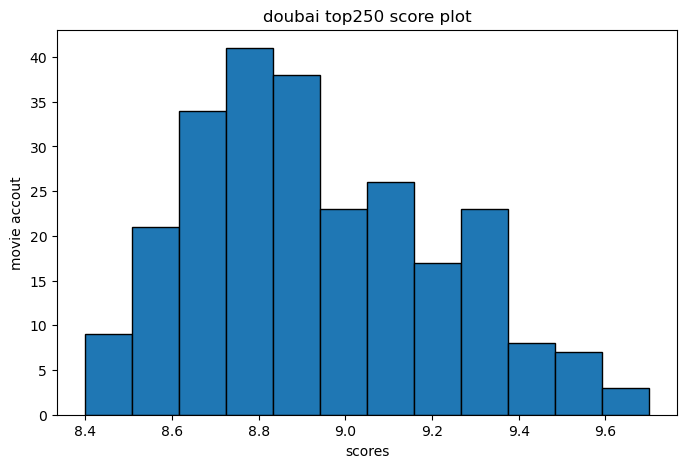

In [9]:
plt.figure(figsize=(8,5))
plt.hist(df["评分"].dropna(),bins=12,edgecolor="black")
plt.xlabel("scores")
plt.ylabel("movie accout")
plt.title("doubai top250 score plot")
save_plot("01_doubai_top250.png")
plt.show()

In [ ]:
### 分析结论
- 豆瓣 Top250 的评分整体明显偏高。
- 大部分电影评分集中在 8.5 分到 9.5 分之间。
- 这是因为 Top250 本身就是经过筛选后的高分榜单，因此低分电影几乎不会出现。

In [ ]:
## 5. 年代趋势折线图
统计每个年代有多少部高分电影进入 Top250，观察经典电影的年代分布。

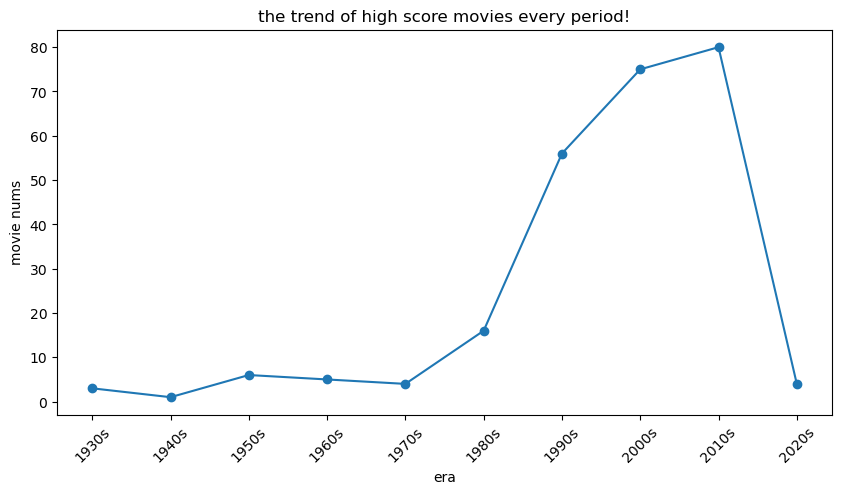

年代
1930s     3
1940s     1
1950s     6
1960s     5
1970s     4
1980s    16
1990s    56
2000s    75
2010s    80
2020s     4
Name: count, dtype: int64

In [10]:
decade_count=(
    df["年代"].dropna()
    .value_counts()
    .sort_index()
)
plt.figure(figsize=(10,5))
plt.plot(decade_count.index, decade_count.values,marker='o')
plt.xlabel("era")
plt.ylabel("movie nums")
plt.title("the trend of high score movies every period!")
plt.xticks(rotation=45)
save_plot("02_highscore_top250.png")
plt.show()

decade_count


In [ ]:
### 分析结论
- 不同年代的高分电影数量存在明显差异。
- 某些电影工业成熟、经典作品集中的年代，在榜单中的占比更高。
- 这说明高分电影不仅和作品质量有关，也与时代背景、产业发展和作品沉淀时间有关。

In [ ]:
## 6. 导演作品数 Top10
统计上榜作品最多的导演，观察哪些导演在豆瓣高分榜中最具影响力。

/var/folders/q8/ls2wnwfn1w1223pjzbk25p1h0000gn/T/ipykernel_32794/1425833632.py:14: UserWarning: Glyph 23467 (\N{CJK UNIFIED IDEOGRAPH-5BAB}) missing from font(s) DejaVu Sans.
  plt.savefig(
/var/folders/q8/ls2wnwfn1w1223pjzbk25p1h0000gn/T/ipykernel_32794/1425833632.py:14: UserWarning: Glyph 23822 (\N{CJK UNIFIED IDEOGRAPH-5D0E}) missing from font(s) DejaVu Sans.
  plt.savefig(
/var/folders/q8/ls2wnwfn1w1223pjzbk25p1h0000gn/T/ipykernel_32794/1425833632.py:14: UserWarning: Glyph 39567 (\N{CJK UNIFIED IDEOGRAPH-9A8F}) missing from font(s) DejaVu Sans.
  plt.savefig(
/var/folders/q8/ls2wnwfn1w1223pjzbk25p1h0000gn/T/ipykernel_32794/1425833632.py:14: UserWarning: Glyph 20811 (\N{CJK UNIFIED IDEOGRAPH-514B}) missing from font(s) DejaVu Sans.
  plt.savefig(
/var/folders/q8/ls2wnwfn1w1223pjzbk25p1h0000gn/T/ipykernel_32794/1425833632.py:14: UserWarning: Glyph 37324 (\N{CJK UNIFIED IDEOGRAPH-91CC}) missing from font(s) DejaVu Sans.
  plt.savefig(
/var/folders/q8/ls2wnwfn1w1223pjzbk25p1h0000gn/T/i

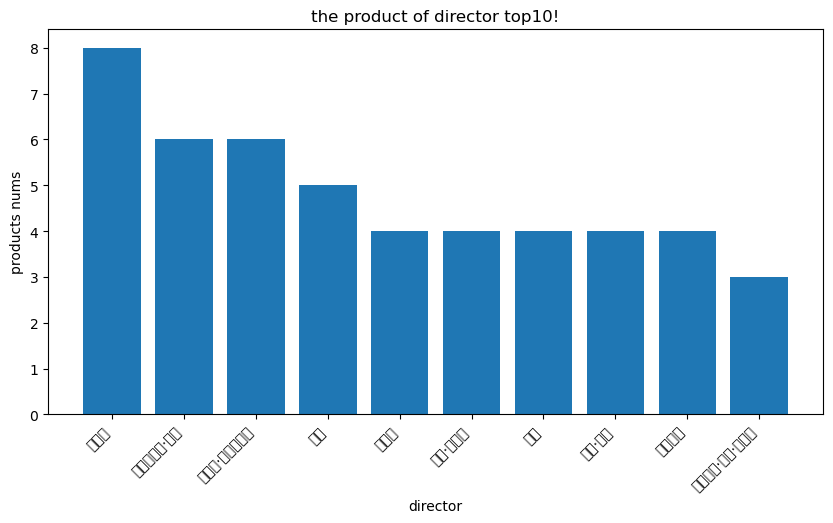

导演
宫崎骏            8
克里斯托弗·诺兰       6
史蒂文·斯皮尔伯格      6
李安             5
王家卫            4
彼特·道格特         4
今敏             4
大卫·芬奇          4
是枝裕和           4
弗朗西斯·福特·科波拉    3
dtype: int64

In [11]:
director_top10=(
    df[df["导演"].astype(str).str.strip() != ""]
    .groupby("导演")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
plt.bar(director_top10.index, director_top10.values)
plt.xlabel("director")
plt.ylabel("products nums")
plt.title("the product of director top10!")
plt.xticks(rotation=45,ha="right")
save_plot("03_highscore_top250.png")
plt.show()

director_top10

In [ ]:
### 分析结论
- 上榜次数多的导演，通常拥有更强的持续创作能力。
- 他们不仅作品数量突出，而且作品整体质量也更容易获得观众认可。
- 这部分导演通常在电影史中具有较高地位，对榜单影响力明显。

In [ ]:
## 7. 类型词云图
将所有电影类型汇总，观察榜单中最常见的题材关键词。

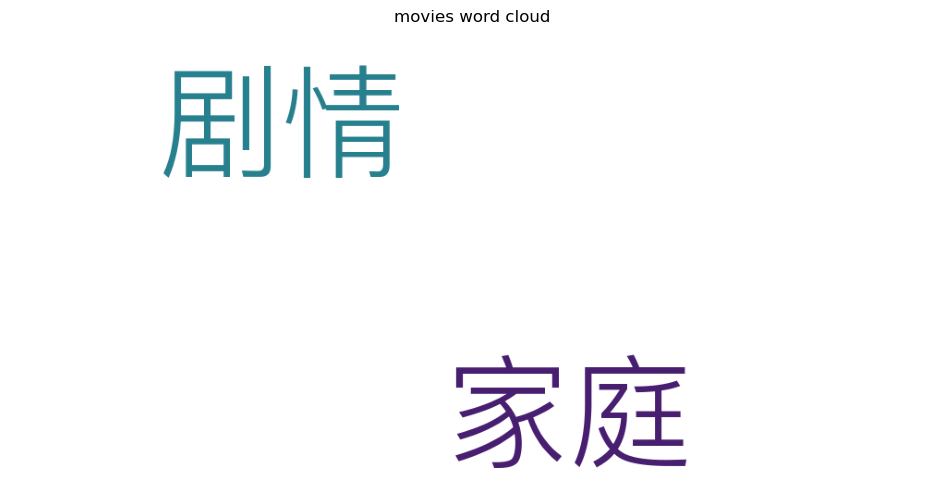

In [12]:
all_genres = []
for genre in df["类型列表"]:
    if isinstance(genre, list):
        all_genres.extend(genre)

genre_text = " ".join(genre)
wc = WordCloud(
        width = 1000,
        height = 500,
        background_color = "white",
        collocations = False,
        font_path = "/Users/kang/Library/Fonts/PingFangSC-Light.ttf",
).generate(genre_text)

plt.figure(figsize=(12,6))
plt.imshow(wc)
plt.axis("off")
plt.title("movies word cloud")
save_plot("04_wordcloud_top250.png")
plt.show()



In [ ]:
### 分析结论
- 词云中字体越大的类型，说明在榜单中出现得越频繁。
- 从高频类型可以看出，剧情、犯罪、爱情、科幻、动画等题材在 Top250 中更受欢迎。
- 这反映出观众对情感表达、故事完成度和类型创新的长期偏好。

In [ ]:
## 8. 评价人数 vs 评分散点图
通过散点图观察电影“口碑”和“热度”之间的关系。

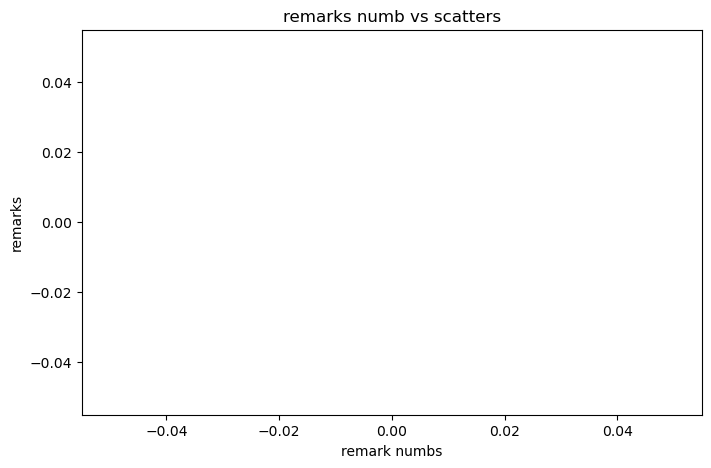

In [14]:
plot_df =df.dropna(subset=["评分", "评价人数"]).copy()
plt.figure(figsize=(8,5))
plt.scatter(plot_df["评价人数"], plot_df["评分"], alpha=0.7)
plt.xlabel("remark numbs")
plt.ylabel("remarks")
plt.title("remarks numb vs scatters")
save_plot("05_remarks_top250.png")
plt.show()

In [ ]:
### 分析结论
- 右上区域的电影通常代表“高评分且高热度”的大众经典。
- 左上区域的电影说明“评分很高但评价人数较少”，这类电影更像冷门佳作。
- 热度高并不一定意味着评分最高，说明大众传播和口碑质量并不完全一致。

In [ ]:
## 9. Top10 电影卡片展示
展示排名前 10 的电影基础信息，并尝试加载海报图片进行展示。

In [16]:
top10 = df.sort_values("排名").head(10)[["排名", "电影名", "评分", "评价人数", "年份", "图片链接"]]
top10

,排名,电影名,评分,评价人数,年份,图片链接
0,1,肖申克的救赎,9.7,NaN,1994,https://img3.doubanio.com/view/photo/s_ratio_p...
1,2,霸王别姬,9.6,NaN,1993,https://img1.doubanio.com/view/photo/s_ratio_p...
2,3,泰坦尼克号,9.5,NaN,1997,https://img9.doubanio.com/view/photo/s_ratio_p...
3,4,阿甘正传,9.5,NaN,1994,https://img3.doubanio.com/view/photo/s_ratio_p...
4,5,千与千寻,9.4,NaN,2001,https://img1.doubanio.com/view/photo/s_ratio_p...
5,6,美丽人生,9.5,NaN,1997,https://img3.doubanio.com/view/photo/s_ratio_p...
6,7,星际穿越,9.4,NaN,2014,https://img3.doubanio.com/view/photo/s_ratio_p...
7,8,这个杀手不太冷,9.4,NaN,1994,https://img9.doubanio.com/view/photo/s_ratio_p...
8,9,盗梦空间,9.4,NaN,2010,https://img9.doubanio.com/view/photo/s_ratio_p...
9,10,楚门的世界,9.4,NaN,1998,https://img3.doubanio.com/view/photo/s_ratio_p...


/var/folders/q8/ls2wnwfn1w1223pjzbk25p1h0000gn/T/ipykernel_32794/689882866.py:34: UserWarning: Glyph 32918 (\N{CJK UNIFIED IDEOGRAPH-8096}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/q8/ls2wnwfn1w1223pjzbk25p1h0000gn/T/ipykernel_32794/689882866.py:34: UserWarning: Glyph 30003 (\N{CJK UNIFIED IDEOGRAPH-7533}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/q8/ls2wnwfn1w1223pjzbk25p1h0000gn/T/ipykernel_32794/689882866.py:34: UserWarning: Glyph 20811 (\N{CJK UNIFIED IDEOGRAPH-514B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/q8/ls2wnwfn1w1223pjzbk25p1h0000gn/T/ipykernel_32794/689882866.py:34: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/q8/ls2wnwfn1w1223pjzbk25p1h0000gn/T/ipykernel_32794/689882866.py:34: UserWarning: Glyph 25937 (\N{CJK UNIFIED IDEOGRAPH-6551}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/q8/ls2wnwfn1

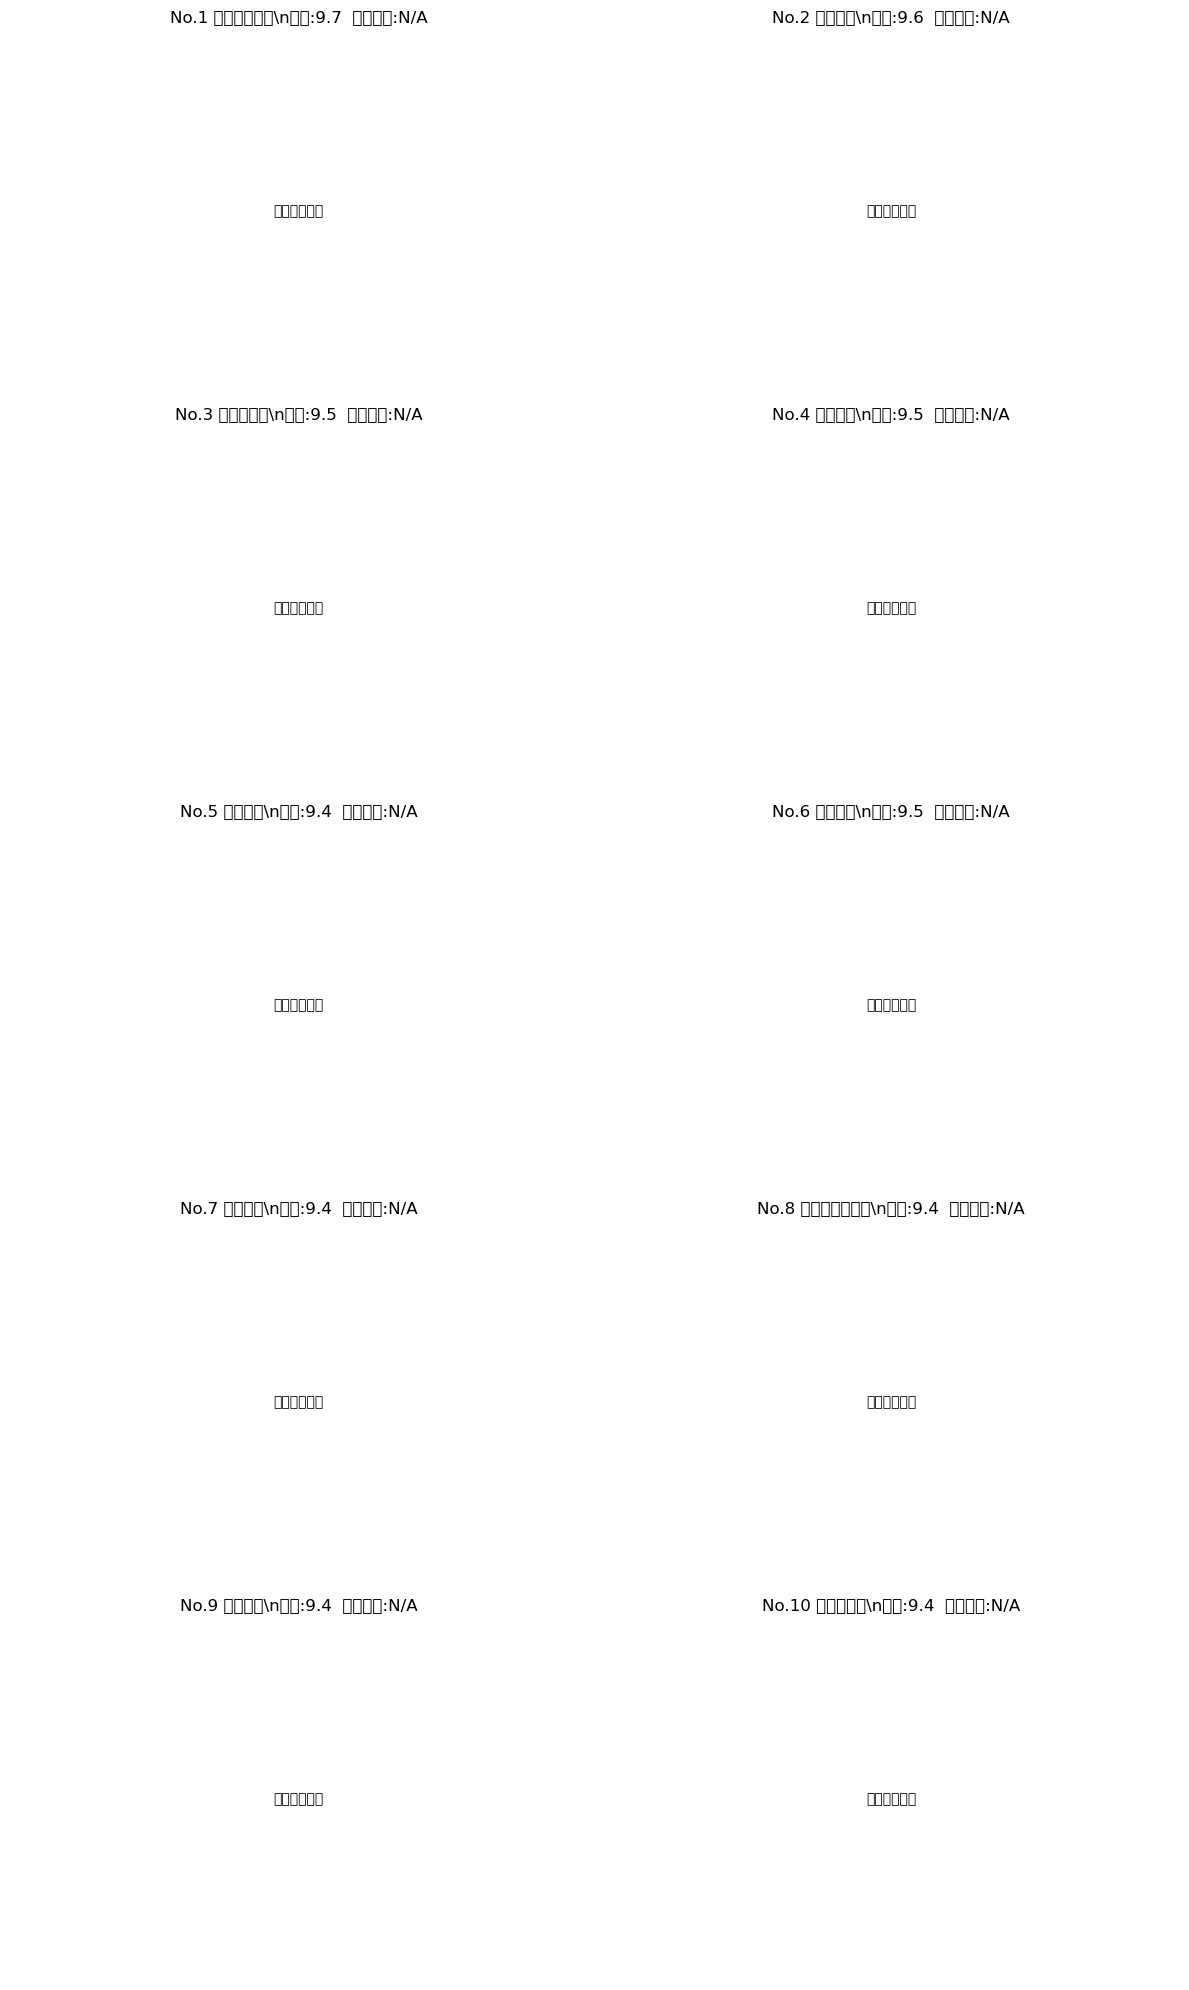

In [17]:
def fetch_image(url, timeout=10):
    try:
        r = requests.get(url, timeout=timeout)
        r.raise_for_status()
        return Image.open(BytesIO(r.content))
    except Exception:
        return None

top10 = df.sort_values("排名").head(10).copy()

n = len(top10)
cols = 2
rows = math.ceil(n / cols)

plt.figure(figsize=(12, rows * 4))

for i, (_, row) in enumerate(top10.iterrows(), start=1):
    plt.subplot(rows, cols, i)
    img = fetch_image(row.get("图片链接", ""))
    if img:
        plt.imshow(img)
        plt.axis("off")
    else:
        plt.text(0.5, 0.5, "图片加载失败", ha="center", va="center")
        plt.axis("off")

    title = str(row["电影名"])
    rank = int(row["排名"]) if pd.notna(row["排名"]) else ""
    score = row["评分"]
    votes = int(row["评价人数"]) if pd.notna(row["评价人数"]) else "N/A"

    plt.title(f"No.{rank} {title}\\n评分:{score}  评价人数:{votes}")

plt.tight_layout()
save_plot("06_TOP10电影卡片展示.png")
plt.show()

In [ ]:
### 分析结论
- 排名前 10 的电影整体评分极高，且多数拥有非常高的评价人数。
- 这说明真正长期稳定占据高位的电影，通常同时具备口碑优势和大众传播能力。
- 通过海报展示，也更直观地增强了分析报告的可读性和展示效果。

In [ ]:
## 10. 总结

本次豆瓣 Top250 数据分析完成了以下内容：

1. 使用直方图分析评分分布，发现高分电影集中在 8.5~9.5 区间。
2. 使用折线图分析年代趋势，观察不同年代的经典电影数量差异。
3. 统计导演作品数 Top10，识别榜单中影响力最强的导演。
4. 通过类型词云识别高频题材，了解观众偏好的电影类型。
5. 通过散点图分析评价人数与评分之间的关系，区分热门大片与冷门佳作。
6. 通过 Top10 电影表格和海报展示，增强报告的直观性。

### 图片输出
运行完成后，所有图表会自动保存到：

```bash
images/